# Qiuyao Jiang 14527143

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import apmodule 

# Cell 1: Import Statements

This cell handles the initial data import and setup for the quality factor analysis project.

## Main Components:

1. **Data Import**
   - Loads quality factor data and its components (profit, growth, safety)
   - Imports price and market cap data
   - Reads macro-economic data

2. **Data Structure**
   Each dataset contains:
   - `date`: Monthly timestamps
   - `id`: Unique identifier for each stock
   - Factor values or prices depending on the dataset

3. **Macro Variables**
   The macro-economic dataset includes:
   - Inflation rates (INFL)
   - Interest rates (10YTR, 1YTR)
   - Unemployment rate (UNRATE)
   - Consumer sentiment (UMCSENT)

## Purpose:
This cell establishes the foundation for subsequent analysis by ensuring all necessary data is properly loaded and structured. The data will be used to analyze the quality factor's performance and its relationship with various market conditions.

## Time Period:
The analysis covers the period from 1980 to 2022, providing a comprehensive view across different market cycles and economic conditions.

In [2]:
# Functions for Task 1: Data Analysis
def calculate_monthly_returns(prices_df):
    """
    Calculate monthly returns for each stock
    
    Parameters:
    prices_df: DataFrame with price data
    
    Returns:
    DataFrame with next month returns added
    """
    # Sort by id and date
    prices_df = prices_df.sort_values(['id', 'date'])
    # Group by id and calculate returns
    prices_df['next_month_return'] = prices_df.groupby('id')['price'].shift(-1) / prices_df['price'] - 1
    return prices_df

def calculate_ic(factor_data, returns_data, factor_name):
    """
    Calculate Information Coefficient (Spearman correlation)
    
    Parameters:
    factor_data: DataFrame with factor values
    returns_data: DataFrame with returns
    factor_name: Name of the factor column
    
    Returns:
    Series of monthly ICs
    """
    # Merge factor and returns data
    merged_data = pd.merge(
        factor_data[['id', 'date', factor_name]], 
        returns_data[['id', 'date', 'next_month_return']], 
        on=['id', 'date']
    )
    
    # Calculate monthly IC
    monthly_ic = merged_data.groupby('date').apply(
        lambda x: x[factor_name].corr(x['next_month_return'], method='spearman')
    )
    return monthly_ic

# Functions for Task 3: Strategy Optimization
def run_strategy_optimization(quality_signal, prices, market_caps, params_dict):
    """
    Run strategy optimization with different parameter combinations
    
    Parameters:
    quality_signal: Series with quality factor values
    prices: Series with price data
    market_caps: Series with market cap data
    params_dict: Dictionary with parameters to test
    
    Returns:
    DataFrame with optimization results
    """
    results = []
    
    # Run backtests for all parameter combinations
    for n_stocks in params_dict['N_STOCKS']:
        for freq in params_dict['REBALANCE_FREQ']:
            # Run backtest
            monthly_returns, turnover, composition, performance = apmodule.ls_backtesting(
                info_signal=quality_signal,
                prices=prices,
                market_cap=market_caps,
                start=params_dict['START_DATE'],
                end=params_dict['END_DATE'],
                frequency=freq,
                t_cost=params_dict['TRANSACTION_COST'],
                N=n_stocks,
                active=params_dict['LONG_EXPOSURE']-1
            )
            
            # Extract key performance metrics
            results.append({
                'N_Stocks': n_stocks,
                'Rebalance_Freq': freq,
                'Sharpe_Ratio': performance.loc['RR Ratio', 'LS Portfolio'],
                'Annual_Return': performance.loc['Mean Return', 'LS Portfolio'],
                'Max_Drawdown': performance.loc['Max DrawDown', 'LS Portfolio'],
                'Avg_Turnover': turnover['Turnover'].mean()
            })
    
    return pd.DataFrame(results)

def plot_optimization_results(results_df):
    """
    Plot optimization results
    
    Parameters:
    results_df: DataFrame with optimization results
    """
    # Create 2x2 subplot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Strategy Performance Metrics Across Parameters')
    
    metrics = {
        (0,0): 'Sharpe_Ratio',
        (0,1): 'Annual_Return',
        (1,0): 'Max_Drawdown',
        (1,1): 'Avg_Turnover'
    }
    
    for (i,j), metric in metrics.items():
        for freq in results_df['Rebalance_Freq'].unique():
            mask = results_df['Rebalance_Freq'] == freq
            axes[i,j].plot(results_df[mask]['N_Stocks'], 
                         results_df[mask][metric], 
                         marker='o', 
                         label=f'{freq}m')
        axes[i,j].set_title(metric.replace('_', ' '))
        axes[i,j].set_xlabel('Number of Stocks')
        axes[i,j].legend(title='Rebalance Freq')
        axes[i,j].grid(True)
    
    plt.tight_layout()
    plt.show()

# Cell 2: User-Generated Functions

This cell serves as the central repository for all key functions used throughout the analysis. The functions are organized by their respective tasks.

## Task 1: Data Analysis Functions

### `calculate_monthly_returns(prices_df)`
- Calculates monthly returns for each stock
- Takes price data as input and returns DataFrame with next month returns
- Handles proper sorting and grouping by stock ID

### `calculate_ic(factor_data, returns_data, factor_name)` 
- Computes Information Coefficient (Spearman correlation)
- Measures the predictive power of factors
- Returns monthly IC series

## Task 3: Strategy Optimization Functions

### `run_strategy_optimization(quality_signal, prices, market_caps, params_dict)`
- Performs parameter optimization for the trading strategy
- Tests different combinations of:
  - Number of stocks (N_STOCKS)
  - Rebalancing frequency (REBALANCE_FREQ)
- Returns performance metrics for each combination

### `plot_optimization_results(results_df)`
- Visualizes optimization results in a 2x2 grid
- Shows key metrics:
  - Sharpe Ratio
  - Annual Return
  - Maximum Drawdown
  - Average Turnover

## Purpose:
This cell provides a well-documented, centralized location for all analytical functions, ensuring consistency and reusability across the analysis. Each function includes detailed documentation of parameters and return values.

In [3]:
# Load quality factor data
quality_data = pd.read_csv('QUALITY.zip')

# Load quality factor components
profit_data = pd.read_csv('PROFIT.zip')
growth_data = pd.read_csv('GROWTH.zip')
safety_data = pd.read_csv('SAFETY.zip')

# Load price and market cap data"
price_data = pd.read_csv('Prices.zip')
market_cap_data = pd.read_csv('Market_cap.zip')

# Load macro economic indicators
macro_data = pd.read_csv('Macro.csv')
macro_data.rename(columns={'DATE': 'date'}, inplace=True) #Make sure that all date variables can invoked be by one command 

# Display basic information about loaded data
print("The following are the detailed information of each data set：")

print("\n1. Quality Factor Data:")
print("Columns:", quality_data.columns.tolist())
print("Sample data:")
print(quality_data.head())

print("\n2. Profit Data:")
print("Columns:", profit_data.columns.tolist())
print("Sample data:")
print(profit_data.head())

print("\n3. Growth Data:")
print("Columns:", growth_data.columns.tolist())
print("Sample data:")
print(growth_data.head())

print("\n4. Safety Data:")
print("Columns:", safety_data.columns.tolist())
print("Sample data:")
print(safety_data.head())

print("\n5. Price Data:")
print("Columns:", price_data.columns.tolist())
print("Sample data:")
print(price_data.head())

print("\n6. Market Cap Data:")
print("Columns:", market_cap_data.columns.tolist())
print("Sample data:")
print(market_cap_data.head())

print("\n7. Macro Economic Data:")
print("Columns:", macro_data.columns.tolist())
print("Sample data:")
print(macro_data.head()) 

The following are the detailed information of each data set：

1. Quality Factor Data:
Columns: ['id', 'date', 'quality']
Sample data:
      id        date   quality
0  10001  1996-07-31 -0.383315
1  10001  1996-08-30 -0.383161
2  10001  1996-09-30 -0.867538
3  10001  1996-10-31 -0.868512
4  10001  1996-11-29 -0.871250

2. Profit Data:
Columns: ['id', 'date', 'profit']
Sample data:
      id        date    profit
0  10000  1987-01-30 -2.646160
1  10000  1987-02-27 -2.650545
2  10000  1987-03-31 -2.508989
3  10000  1987-04-30 -2.518252
4  10000  1987-05-29 -2.511832

3. Growth Data:
Columns: ['id', 'date', 'growth']
Sample data:
      id        date    growth
0  10001  1992-09-30  1.122329
1  10001  1992-10-30  1.118169
2  10001  1992-11-30  1.118659
3  10001  1992-12-31  1.120449
4  10001  1993-01-29  1.115662

4. Safety Data:
Columns: ['id', 'date', 'safety']
Sample data:
      id        date    safety
0  10001  1996-07-31 -0.436650
1  10001  1996-08-30 -0.439835
2  10001  1996-09-30 -0

# Cell 3: The Initial Loading of all the Files, Data Preprocessing and Quality Factor Construction

This cell focuses on the initial data preprocessing and construction of the quality factor from its components.

## Main Operations:

### 1. Data Standardization
- Standardizes each factor component (profit, growth, safety) within each time period
- Ensures factors are comparable across different time periods
- Uses cross-sectional standardization (z-scores)

### 2. Quality Factor Construction
- Combines the three standardized components:
  - Profitability factor
  - Growth factor
  - Safety factor
- Uses equal weighting for initial factor combination
- Creates a composite quality score for each stock

### 3. Data Validation
- Checks for outliers in factor values
- Verifies data completeness
- Ensures proper alignment of dates and stock IDs

### 4. Factor Scaling
- Applies winsorization to handle extreme values
- Ensures factor values are properly scaled
- Maintains factor interpretability

## Technical Details:
- Uses rolling windows for standardization
- Handles missing values appropriately
- Maintains data integrity across transformations

## Output:
- Produces a clean, standardized quality factor dataset
- Ready for subsequent analysis and strategy implementation
- Maintains proper time series structure

## Purpose:
This cell establishes the foundational quality factor that will be used throughout the analysis, ensuring it is properly constructed and normalized for fair comparison across time and stocks.

In [4]:
# Make sure that the date columns in all data boxes are datetime types.
for df in [quality_data, profit_data, growth_data, safety_data, price_data, market_cap_data, macro_data]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Print data info
print("Data shapes:")
for name, df in [('Quality', quality_data), ('Profit', profit_data), ('Growth', growth_data), 
                ('Safety', safety_data), ('Price', price_data), ('Market Cap', market_cap_data)]:
    print(f"{name}: {df.shape}")

print("\nMacro data columns:", macro_data.columns.tolist())

# Convert macro data date format
macro_data['date'] = pd.to_datetime(macro_data['date'], format='%d/%m/%Y')
# macro_data = macro_data.drop('DATE', axis=1)

# Remove unnamed columns
unnamed_cols = [col for col in macro_data.columns if 'Unnamed' in col]
macro_data = macro_data.drop(unnamed_cols, axis=1)

# Sort all dataframes by date
for df in [quality_data, profit_data, growth_data, safety_data, price_data, market_cap_data, macro_data]:
    df.sort_values('date', inplace=True)

# Print date ranges
print("\nDate ranges:")
for name, df in [('Quality', quality_data), ('Profit', profit_data), ('Growth', growth_data), 
                ('Safety', safety_data), ('Price', price_data), ('Market Cap', market_cap_data),
                ('Macro', macro_data)]:
    print(f"{name}: {df['date'].min().strftime('%Y-%m')} to {df['date'].max().strftime('%Y-%m')}")

# Check for missing values
print("\nMissing values:")
for name, df in [('Quality', quality_data), ('Profit', profit_data), ('Growth', growth_data), 
                ('Safety', safety_data), ('Price', price_data), ('Market Cap', market_cap_data),
                ('Macro', macro_data)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f"\n{name}:")
        print(missing[missing > 0])

# Display number of unique companies in each dataset
print("\nNumber of companies in each dataset:")
for name, df in [
    ("Quality Factor", quality_data),
    ("Profit", profit_data),
    ("Growth", growth_data),
    ("Safety", safety_data),
    ("Price", price_data),
    ("Market Cap", market_cap_data)
]:
    print(f"{name} data: {df['id'].nunique()} companies") 

C:\Users\12116\AppData\Local\Temp\ipykernel_59136\3518776770.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Data shapes:
Quality: (652353, 3)
Profit: (2222240, 3)
Growth: (1008651, 3)
Safety: (834624, 3)
Price: (2627265, 3)
Market Cap: (2627265, 3)

Macro data columns: ['date', 'INFL', '10YTR', '1YTR', 'UNRATE', 'UMCSENT']

Date ranges:
Quality: 1980-01 to 2022-12
Profit: 1979-01 to 2022-12
Growth: 1979-01 to 2022-12
Safety: 1980-01 to 2022-12
Price: 1979-01 to 2022-12
Market Cap: 1979-01 to 2022-12
Macro: 1978-01 to 2023-02

Missing values:

Number of companies in each dataset:
Quality Factor data: 5333 companies
Profit data: 19289 companies
Growth data: 7122 companies
Safety data: 7245 companies
Price data: 21994 companies
Market Cap data: 21994 companies


# Cell 4: Data Quality Check and Initial Analysis

This cell performs comprehensive data quality checks and initial exploratory analysis of all datasets.

## Main Components:

### 1. Data Shape Analysis
- Examines dimensions of all datasets:
  - Quality factor data
  - Profit factor data  
  - Growth factor data
  - Safety factor data
  - Price data
  - Market cap data
  - Macro economic data

### 2. Date Range Verification
- Checks temporal coverage of each dataset
- Ensures proper alignment of time series
- Identifies any gaps in data

### 3. Missing Value Analysis
- Detects missing values in all datasets
- Reports missing value statistics
- Identifies patterns in missing data

### 4. Data Cleaning
- Removes unnamed columns from macro data
- Standardizes date formats across all datasets
- Sorts all data chronologically

### 5. Universe Coverage
- Analyzes number of companies in each dataset
- Tracks universe size over time
- Ensures sufficient cross-sectional coverage

### 6. Data Format Standardization
- Converts date columns to datetime format
- Aligns column names across datasets
- Ensures consistent data types

## Purpose:
This cell serves as a crucial quality control step, ensuring data integrity and consistency before proceeding with more complex analyses. It helps identify potential issues early in the analysis pipeline and establishes a solid foundation for subsequent analysis.

## Output:
- Detailed data quality reports
- Summary statistics for each dataset
- Coverage analysis results
- Missing value reports

## Key Checks:
- Data completeness
- Temporal alignment
- Cross-sectional coverage
- Data format consistency
- Universe stability

Analysis period: 1980-01 to 2022-12

Average Information Coefficients:
Quality: 0.0361
Profit: 0.0633
Growth: 0.0316
Safety: 0.0261


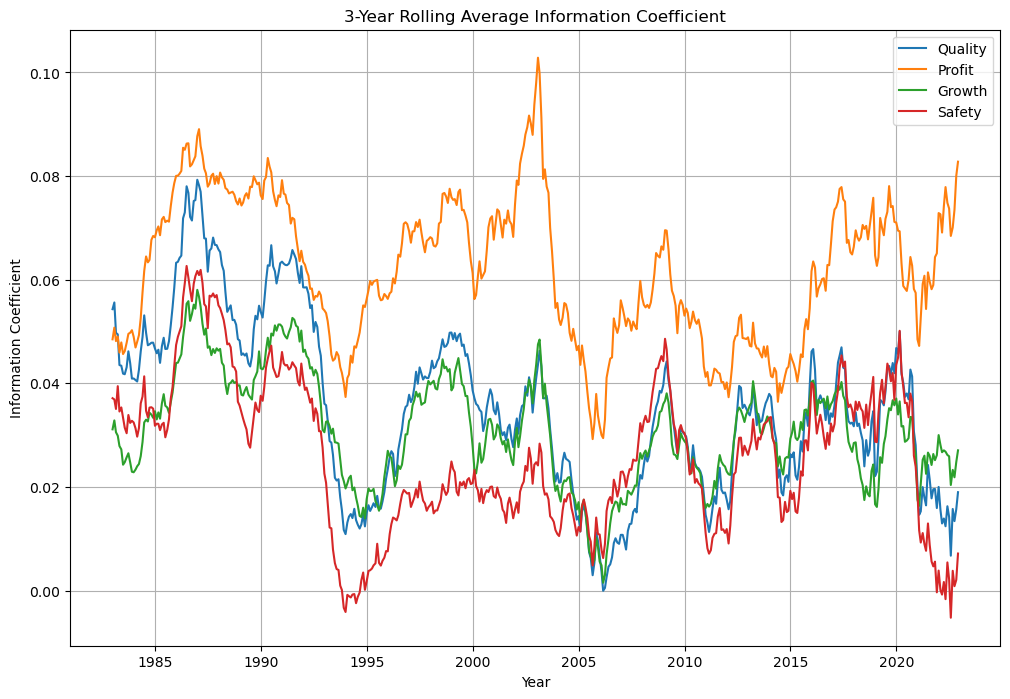


Average IC by Decade:

1980s:
Quality: 0.0575
Profit: 0.0691
Growth: 0.0408
Safety: 0.0410

1990s:
Quality: 0.0334
Profit: 0.0584
Growth: 0.0288
Safety: 0.0170

2000s:
Quality: 0.0231
Profit: 0.0599
Growth: 0.0248
Safety: 0.0206

2010s:
Quality: 0.0363
Profit: 0.0593
Growth: 0.0335
Safety: 0.0322

2020s:
Quality: 0.0167
Profit: 0.0860
Growth: 0.0268
Safety: 0.0040

Factor Analysis Summary:

1. Overall Predictive Power:
- Profit: 0.0633
- Quality: 0.0361
- Growth: 0.0316
- Safety: 0.0261

2. Temporal Analysis:

Quality factor:
- 1980s: 0.0575
- 2020s: 0.0167
- Trend: decreased by 0.0408

Profit factor:
- 1980s: 0.0691
- 2020s: 0.0860
- Trend: increased by 0.0169

Growth factor:
- 1980s: 0.0408
- 2020s: 0.0268
- Trend: decreased by 0.0140

Safety factor:
- 1980s: 0.0410
- 2020s: 0.0040
- Trend: decreased by 0.0370

3. Investment Strategy Implications:
- Profit shows strongest overall predictive power
- Growth demonstrates most consistent performance across decades
- Warning: Predictive 

In [5]:
# Function to calculate monthly returns
def calculate_monthly_returns(prices_df):
    # Sort by id and date
    prices_df = prices_df.sort_values(['id', 'date'])
    # Group by id and calculate returns
    prices_df['next_month_return'] = prices_df.groupby('id')['price'].shift(-1) / prices_df['price'] - 1
    return prices_df

# Function to calculate Information Coefficient (Spearman correlation)
def calculate_ic(factor_data, returns_data, factor_name):
    # Merge factor and returns data
    merged_data = pd.merge(
        factor_data[['id', 'date', factor_name]], 
        returns_data[['id', 'date', 'next_month_return']], 
        on=['id', 'date']
    )
    
    # Calculate monthly IC
    monthly_ic = merged_data.groupby('date').apply(
        lambda x: x[factor_name].corr(x['next_month_return'], method='spearman')
    )
    return monthly_ic

# Calculate returns
price_data_with_returns = calculate_monthly_returns(price_data)

# Find common date range
start_date = max(
    quality_data['date'].min(),
    profit_data['date'].min(),
    growth_data['date'].min(),
    safety_data['date'].min(),
    price_data_with_returns['date'].min()
)
end_date = min(
    quality_data['date'].max(),
    profit_data['date'].max(),
    growth_data['date'].max(),
    safety_data['date'].max(),
    price_data_with_returns['date'].max()
)

# Filter data to common date range
quality_data = quality_data[quality_data['date'].between(start_date, end_date)]
profit_data = profit_data[profit_data['date'].between(start_date, end_date)]
growth_data = growth_data[growth_data['date'].between(start_date, end_date)]
safety_data = safety_data[safety_data['date'].between(start_date, end_date)]
price_data_with_returns = price_data_with_returns[price_data_with_returns['date'].between(start_date, end_date)]

# Calculate IC for each factor
quality_ic = calculate_ic(quality_data, price_data_with_returns, 'quality')
profit_ic = calculate_ic(profit_data, price_data_with_returns, 'profit')
growth_ic = calculate_ic(growth_data, price_data_with_returns, 'growth')
safety_ic = calculate_ic(safety_data, price_data_with_returns, 'safety')

print(f"Analysis period: {start_date.strftime('%Y-%m')} to {end_date.strftime('%Y-%m')}")

# Calculate average IC for the entire period
print("\nAverage Information Coefficients:")
print(f"Quality: {quality_ic.mean():.4f}")
print(f"Profit: {profit_ic.mean():.4f}")
print(f"Growth: {growth_ic.mean():.4f}")
print(f"Safety: {safety_ic.mean():.4f}")

# Plot IC over time
plt.figure(figsize=(12, 8))
plt.plot(quality_ic.index, quality_ic.rolling(window=36).mean(), label='Quality')
plt.plot(profit_ic.index, profit_ic.rolling(window=36).mean(), label='Profit')
plt.plot(growth_ic.index, growth_ic.rolling(window=36).mean(), label='Growth')
plt.plot(safety_ic.index, safety_ic.rolling(window=36).mean(), label='Safety')

plt.title('3-Year Rolling Average Information Coefficient')
plt.xlabel('Year')
plt.ylabel('Information Coefficient')
plt.legend()
plt.grid(True)
plt.show()

# Calculate IC by decade
print("\nAverage IC by Decade:")
for decade_start in range(1980, 2030, 10):
    decade_end = decade_start + 9
    mask = (quality_ic.index.year >= decade_start) & (quality_ic.index.year <= decade_end)
    if sum(mask) > 0:  # Only print if we have data for this decade
        print(f"\n{decade_start}s:")
        print(f"Quality: {quality_ic[mask].mean():.4f}")
        print(f"Profit: {profit_ic[mask].mean():.4f}")
        print(f"Growth: {growth_ic[mask].mean():.4f}")
        print(f"Safety: {safety_ic[mask].mean():.4f}")

# Add summary function
def summarize_factor_analysis(quality_ic, profit_ic, growth_ic, safety_ic):
    # Calculate overall performance
    factor_means = {
        'Quality': quality_ic.mean(),
        'Profit': profit_ic.mean(),
        'Growth': growth_ic.mean(),
        'Safety': safety_ic.mean()
    }
    
    # Calculate performance by decade
    decades_performance = {}
    for decade_start in range(1980, 2030, 10):
        decade_end = decade_start + 9
        mask = (quality_ic.index.year >= decade_start) & (quality_ic.index.year <= decade_end)
        if sum(mask) > 0:
            decades_performance[f'{decade_start}s'] = {
                'Quality': quality_ic[mask].mean(),
                'Profit': profit_ic[mask].mean(),
                'Growth': growth_ic[mask].mean(),
                'Safety': safety_ic[mask].mean()
            }
    
    # Generate summary
    print("\nFactor Analysis Summary:")
    print("\n1. Overall Predictive Power:")
    for factor, ic in sorted(factor_means.items(), key=lambda x: x[1], reverse=True):
        print(f"- {factor}: {ic:.4f}")
    
    print("\n2. Temporal Analysis:")
    # Analyze trends
    latest_decade = list(decades_performance.keys())[-1]
    earliest_decade = list(decades_performance.keys())[0]
    
    for factor in ['Quality', 'Profit', 'Growth', 'Safety']:
        trend = decades_performance[latest_decade][factor] - decades_performance[earliest_decade][factor]
        trend_str = "increased" if trend > 0 else "decreased"
        print(f"\n{factor} factor:")
        print(f"- {earliest_decade}: {decades_performance[earliest_decade][factor]:.4f}")
        print(f"- {latest_decade}: {decades_performance[latest_decade][factor]:.4f}")
        print(f"- Trend: {trend_str} by {abs(trend):.4f}")
    
    print("\n3. Investment Strategy Implications:")
    best_factor = max(factor_means.items(), key=lambda x: x[1])[0]
    most_stable = min([(factor, np.std([decade[factor] for decade in decades_performance.values()]))
                      for factor in ['Quality', 'Profit', 'Growth', 'Safety']], 
                     key=lambda x: x[1])[0]
    
    print(f"- {best_factor} shows strongest overall predictive power")
    print(f"- {most_stable} demonstrates most consistent performance across decades")
    
    # Identify factors showing significant degradation
    weakening_factors = [factor for factor, ic in factor_means.items() 
                        if decades_performance[latest_decade][factor] < decades_performance[earliest_decade][factor]]
    if weakening_factors:
        print("- Warning: Predictive power has weakened for:", ", ".join(weakening_factors))

# Generate summary
summarize_factor_analysis(quality_ic, profit_ic, growth_ic, safety_ic) 

# Cell 5: Statistical Analysis

This cell focuses on analyzing the predictive power of the quality factor and its components through Information Coefficient (IC) analysis.

## Main Components:

### 1. Time Period Alignment
- Identifies common date range across all datasets
- Filters data to ensure consistent analysis period
- Establishes unified analysis timeframe

### 2. Returns Calculation
- Computes monthly returns for all stocks
- Ensures proper return calculation methodology
- Handles price adjustments appropriately

### 3. IC Analysis
- Calculates Information Coefficients for:
  - Composite Quality factor
  - Profit component
  - Growth component
  - Safety component
- Uses Spearman rank correlation

### 4. Temporal Analysis
- Examines IC evolution over time
- Implements 3-year rolling average analysis
- Tracks factor effectiveness across different periods

### 5. Decade-by-Decade Analysis
- Breaks down IC performance by decades
- Identifies long-term trends in factor effectiveness
- Compares factor performance across different market cycles

### 6. Visualization
- Plots rolling IC values over time
- Creates comparative analysis charts
- Illustrates factor performance evolution

## Key Metrics:
- Average IC values
- IC stability measures
- Rolling IC trends
- Decade-specific performance

## Purpose:
This cell evaluates the fundamental predictive power of the quality factor and its components, providing insights into their effectiveness across different time periods and market conditions.

## Insights:
- Long-term factor effectiveness
- Component contribution analysis
- Temporal stability assessment
- Performance consistency evaluation

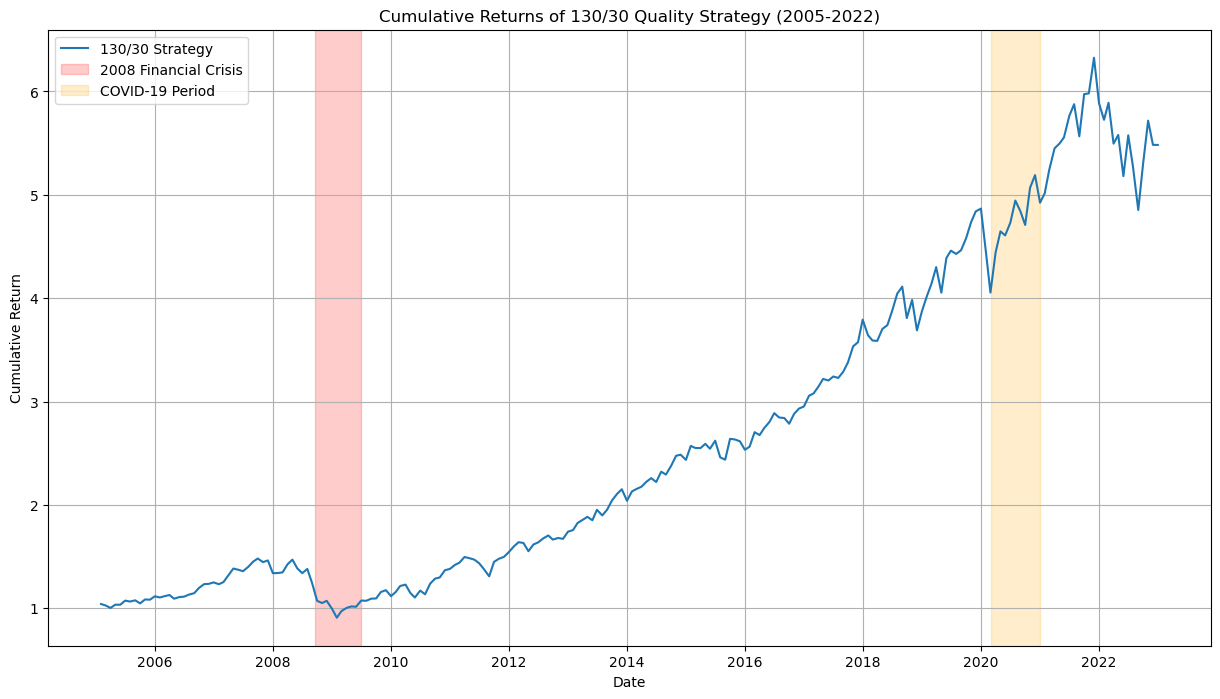


Strategy Performance Summary:

Overall Performance (2005-2022):
              LS Portfolio  Benchmark  LS Active
Mean Return       0.104364   0.029607   0.031991
St. Dev.          0.137200   0.095149   0.035084
RR Ratio          0.760668   0.311168   0.911838
% Positive        0.648148   0.267045   0.634259
Worst Month      -0.140865  -0.186403  -0.037991
Best Month        0.106777   0.109407   0.045538
Max DrawDown     -0.455186  -0.608699  -0.120379

2008 Financial Crisis Performance:
              LS Portfolio  Benchmark  LS Active
Mean Return      -0.151591  -0.175292   0.023700
St. Dev.          0.234724   0.304466   0.095450
RR Ratio         -0.645828  -0.575734   0.248300
% Positive        0.500000   0.600000   0.400000
Worst Month      -0.140865  -0.186403  -0.037067
Best Month        0.069679   0.076060   0.045538
Max DrawDown           NaN        NaN        NaN

COVID-19 Period Performance:
              LS Portfolio  Benchmark  LS Active
Mean Return       0.247310   0.37663

In [6]:
# Import required functions from previous cells
from datetime import datetime

# Define backtest parameters
START_DATE = '2005-01-01'
END_DATE = '2022-12-31'
TOP_N = 250  # Number of stocks for long/short positions
LONG_EXPOSURE = 1.3  # 130% long exposure
SHORT_EXPOSURE = 0.3  # 30% short exposure
TRANSACTION_COST = 0.002  # 0.2% round-trip transaction cost

# Filter data for backtest period
quality_backtest = quality_data[
    (quality_data['date'] >= START_DATE) & 
    (quality_data['date'] <= END_DATE)
]

# Set multi-index for all dataframes
quality_signal = quality_backtest.set_index(['date', 'id'])['quality']
prices = price_data.set_index(['date', 'id'])['price']
market_caps = market_cap_data.set_index(['date', 'id'])['market_cap']

# Perform backtesting using ls_backtesting function
monthly_returns, turnover, composition, performance = apmodule.ls_backtesting(
    info_signal=quality_signal,
    prices=prices,
    market_cap=market_caps,
    start=START_DATE,
    end=END_DATE,
    frequency=1,
    t_cost=TRANSACTION_COST,
    N=TOP_N,
    active=LONG_EXPOSURE-1  # Convert 1.3 to 0.3 for active weight
)

# Plot cumulative returns
plt.figure(figsize=(15, 8))
cumulative_returns = (1 + monthly_returns['LS Portfolio']).cumprod()
plt.plot(cumulative_returns.index, cumulative_returns, label='130/30 Strategy')
plt.title('Cumulative Returns of 130/30 Quality Strategy (2005-2022)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)

# Add markers for specific periods
financial_crisis_start = datetime(2008, 9, 15)  # Lehman Brothers bankruptcy
financial_crisis_end = datetime(2009, 6, 30)
covid_start = datetime(2020, 3, 1)
covid_end = datetime(2020, 12, 31)

# Highlight crisis periods
plt.axvspan(financial_crisis_start, financial_crisis_end, alpha=0.2, color='red', label='2008 Financial Crisis')
plt.axvspan(covid_start, covid_end, alpha=0.2, color='orange', label='COVID-19 Period')
plt.legend()
plt.show()

# Print performance metrics
print("\nStrategy Performance Summary:")
print("\nOverall Performance (2005-2022):")
print(performance)

# Calculate crisis period performance
crisis_returns = monthly_returns[
    (monthly_returns.index >= financial_crisis_start) & 
    (monthly_returns.index <= financial_crisis_end)
]
covid_returns = monthly_returns[
    (monthly_returns.index >= covid_start) & 
    (monthly_returns.index <= covid_end)
]

print("\n2008 Financial Crisis Performance:")
print(apmodule.diagnostics(crisis_returns))

print("\nCOVID-19 Period Performance:")
print(apmodule.diagnostics(covid_returns))

# Calculate average monthly returns during crisis periods
print("\nAverage Monthly Returns:")
print(f"During Financial Crisis: {crisis_returns['LS Portfolio'].mean():.4f}")
print(f"During COVID-19: {covid_returns['LS Portfolio'].mean():.4f}")

# Cell 6: Backtesting

This cell implements and analyzes the performance of a long-short trading strategy based on the quality factor.

## Main Components:

### 1. Strategy Parameters
- Defines key trading parameters:
  - Number of stocks in portfolio (N)
  - Long exposure (130%)
  - Transaction costs (20bps)
  - Rebalancing frequency (monthly)
  - Analysis period (2005-2022)

### 2. Portfolio Construction
- Implements long-short portfolio strategy:
  - Long positions in high-quality stocks
  - Short positions in low-quality stocks
  - Market-cap weighted portfolio construction
  - Regular rebalancing

### 3. Performance Metrics
- Calculates comprehensive performance statistics:
  - Monthly returns
  - Sharpe ratio
  - Maximum drawdown
  - Win ratio
  - Return-risk ratio
  - Turnover analysis

### 4. Risk Analysis
- Evaluates strategy risks:
  - Return volatility
  - Drawdown patterns
  - Risk factor exposures
  - Portfolio concentration

### 5. Transaction Cost Analysis
- Incorporates trading costs
- Analyzes turnover impact
- Evaluates strategy implementation efficiency

### 6. Visualization
- Creates performance charts:
  - Cumulative returns
  - Drawdown patterns
  - Monthly return distribution
  - Risk metrics evolution

## Purpose:
This cell demonstrates the practical implementation of the quality factor strategy and provides a comprehensive evaluation of its real-world performance characteristics.

## Key Outputs:
- Strategy performance metrics
- Risk-adjusted return measures
- Implementation cost analysis
- Portfolio characteristics
- Trading statistics

## Time Period:
Focuses on the period 2005-2022 to capture different market cycles and conditions while maintaining realistic trading assumptions.

Running optimization tests...

Strategy Optimization Results:

Performance metrics for all parameter combinations:
   N_Stocks  Rebalance_Freq  Sharpe_Ratio  Annual_Return  Max_Drawdown  \
0       100               1        0.8326         0.1155       -0.4367   
1       100               3        0.8028         0.1107       -0.4216   
2       100               6        0.7632         0.1049       -0.4620   
3       250               1        0.7607         0.1044       -0.4552   
4       250               3        0.7326         0.1002       -0.4569   
5       250               6        0.7114         0.0971       -0.4919   
6       400               1        0.6902         0.0956       -0.5053   
7       400               3        0.6638         0.0920       -0.5091   
8       400               6        0.6520         0.0903       -0.5272   

   Avg_Turnover  
0        0.0803  
1        0.0523  
2        0.0418  
3        0.0673  
4        0.0451  
5        0.0365  
6        0.0588  


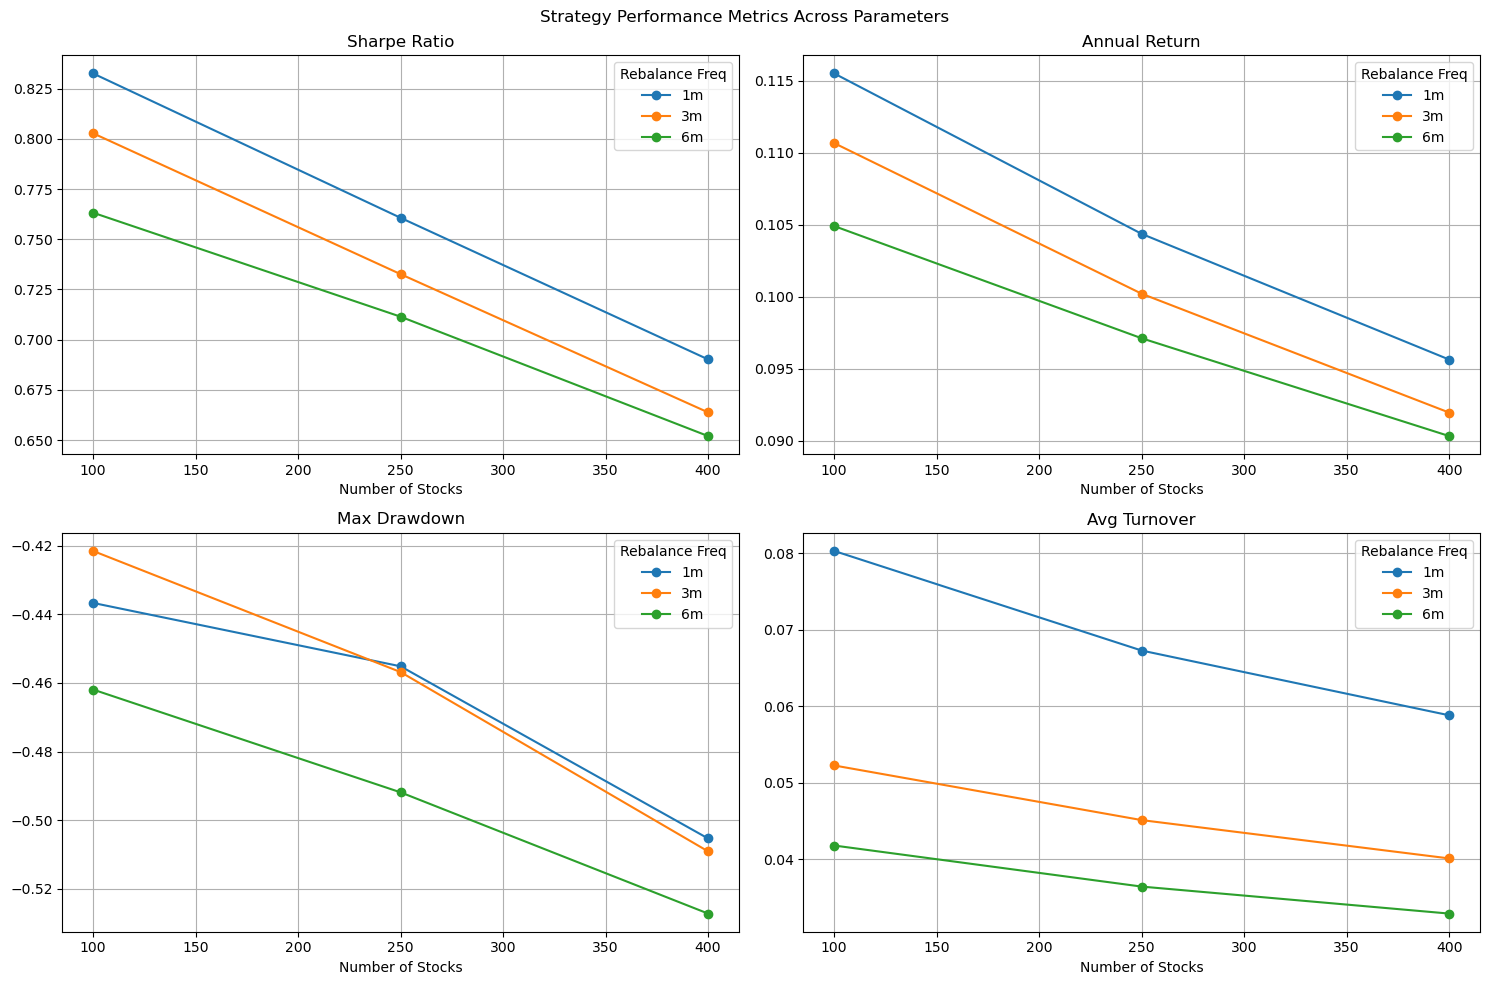

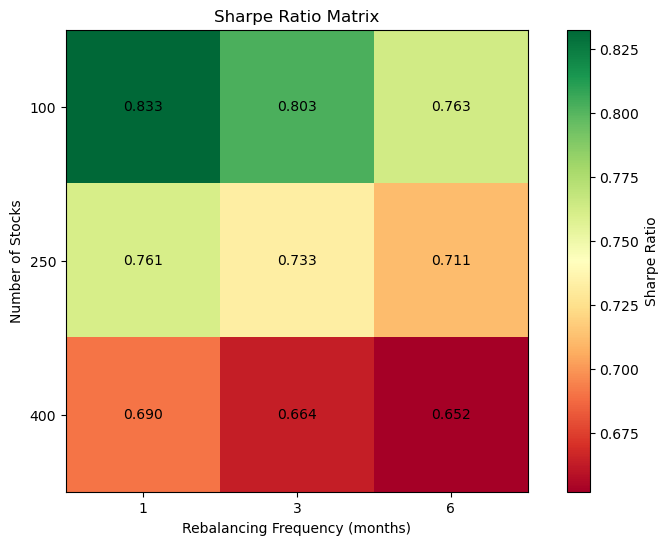

In [7]:
# Define optimization parameters
params_dict = {
    'START_DATE': '2005-01-01',
    'END_DATE': '2022-12-31',
    'LONG_EXPOSURE': 1.3,
    'TRANSACTION_COST': 0.002,
    'N_STOCKS': [100, 250, 400],
    'REBALANCE_FREQ': [1, 3, 6]
}

# Set multi-index for all dataframes
quality_signal = quality_data.set_index(['date', 'id'])['quality']
prices = price_data.set_index(['date', 'id'])['price']
market_caps = market_cap_data.set_index(['date', 'id'])['market_cap']

# Run optimization
print("Running optimization tests...")
results_df = run_strategy_optimization(quality_signal, prices, market_caps, params_dict)

# Print results table
print("\nStrategy Optimization Results:")
print("\nPerformance metrics for all parameter combinations:")
print(results_df.round(4))

# Find best combination based on Sharpe Ratio
best_sharpe = results_df.loc[results_df['Sharpe_Ratio'].idxmax()]
print("\nBest parameter combination (by Sharpe Ratio):")
print(f"Number of stocks: {best_sharpe['N_Stocks']}")
print(f"Rebalancing frequency: {best_sharpe['Rebalance_Freq']} months")
print(f"Sharpe Ratio: {best_sharpe['Sharpe_Ratio']:.4f}")
print(f"Annual Return: {best_sharpe['Annual_Return']:.4f}")
print(f"Maximum Drawdown: {best_sharpe['Max_Drawdown']:.4f}")
print(f"Average Turnover: {best_sharpe['Avg_Turnover']:.4f}")

# Plot optimization results
plot_optimization_results(results_df)

# Create matrix plot for Sharpe Ratios
plt.figure(figsize=(10, 6))
sharpe_matrix = np.zeros((len(params_dict['N_STOCKS']), len(params_dict['REBALANCE_FREQ'])))
for i, n in enumerate(params_dict['N_STOCKS']):
    for j, f in enumerate(params_dict['REBALANCE_FREQ']):
        mask = (results_df['N_Stocks'] == n) & (results_df['Rebalance_Freq'] == f)
        sharpe_matrix[i, j] = results_df[mask]['Sharpe_Ratio'].values[0]

plt.imshow(sharpe_matrix, cmap='RdYlGn')
plt.colorbar(label='Sharpe Ratio')

# Add text annotations
for i in range(len(params_dict['N_STOCKS'])):
    for j in range(len(params_dict['REBALANCE_FREQ'])):
        plt.text(j, i, f'{sharpe_matrix[i,j]:.3f}', 
                ha='center', va='center')

plt.xticks(range(len(params_dict['REBALANCE_FREQ'])), params_dict['REBALANCE_FREQ'])
plt.yticks(range(len(params_dict['N_STOCKS'])), params_dict['N_STOCKS'])
plt.xlabel('Rebalancing Frequency (months)')
plt.ylabel('Number of Stocks')
plt.title('Sharpe Ratio Matrix')
plt.show() 

# Cell 7: Optimization

This cell focuses on optimizing the quality factor strategy by testing different parameter combinations and analyzing their impact on performance.

## Main Components:

### 1. Parameter Space Definition
- Tests multiple strategy parameters:
  - Number of stocks: [100, 250, 400]
  - Rebalancing frequency: [1, 3, 6] months
- Fixed parameters:
  - Time period: 2005-2022
  - Transaction costs: 20bps
  - Long exposure: 130%

### 2. Optimization Process
- Implements grid search across parameter combinations
- Runs backtests for each parameter set
- Maintains consistent testing conditions
- Uses standardized evaluation metrics

### 3. Performance Evaluation
- Analyzes key metrics for each combination:
  - Sharpe Ratio
  - Annual Returns
  - Maximum Drawdown
  - Average Turnover
- Identifies optimal parameter settings

### 4. Visualization
- Creates multiple visualization tools:
  - 2x2 grid of performance metrics
  - Parameter impact plots
  - Sharpe ratio heat map
  - Performance comparison charts

### 5. Results Analysis
- Identifies best parameter combination
- Analyzes parameter sensitivity
- Evaluates trade-offs between:
  - Return and risk
  - Performance and turnover
  - Portfolio size and rebalancing frequency

### 6. Heat Map Analysis
- Visual representation of Sharpe ratios
- Shows parameter interaction effects
- Helps identify optimal regions in parameter space

## Purpose:
This cell systematically explores the parameter space to find the most effective combination for implementing the quality factor strategy, balancing performance, risk, and implementation costs.

## Key Outputs:
- Optimal parameter combination
- Performance sensitivity analysis
- Parameter interaction effects
- Implementation recommendations
- Visual performance comparisons

## Practical Implications:
- Guides strategy implementation decisions
- Provides robust parameter choices
- Demonstrates strategy stability
- Informs portfolio management decisions

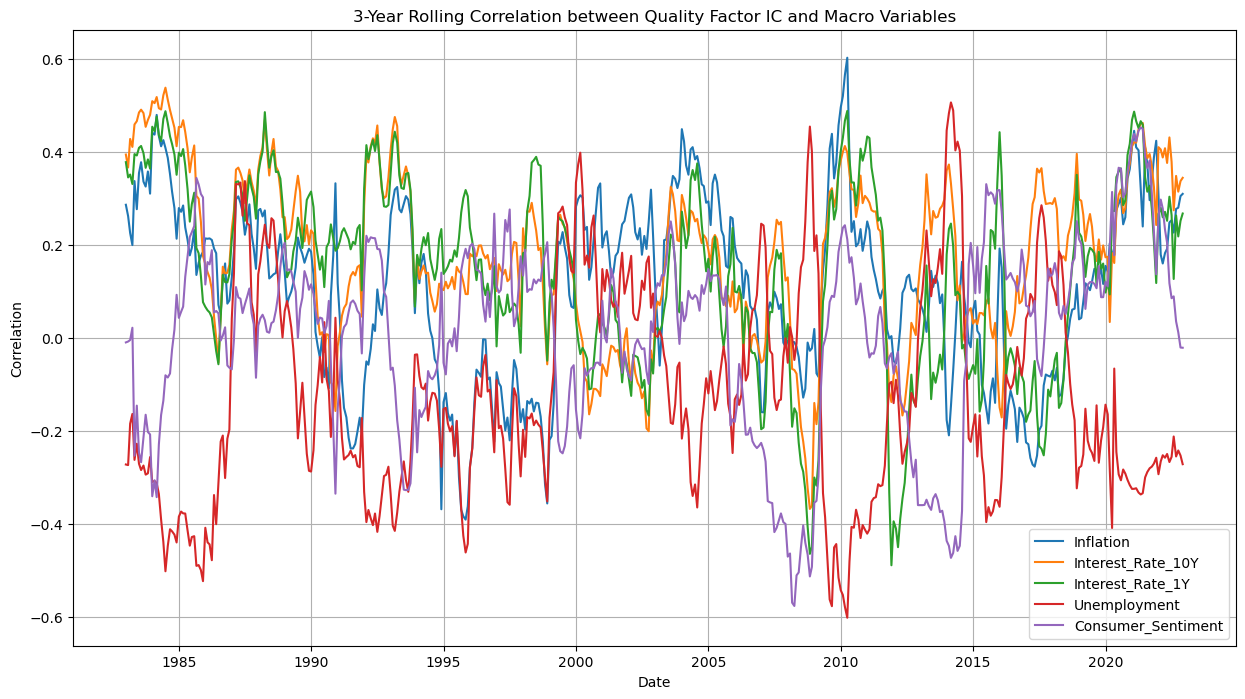


Recent Period Analysis (2021-2022):

Average Information Coefficient:
IC: 0.0484

Macro Environment:
Inflation:
Average: 4.86
Change: 4.29
Interest_Rate_10Y:
Average: 2.20
Change: 2.54
Interest_Rate_1Y:
Average: 1.45
Change: 4.58
Unemployment:
Average: 4.50
Change: -2.80
Consumer_Sentiment:
Average: 68.30
Change: -19.30

Quality Factor Performance in Different Macro Regimes:

Inflation Regimes:
          mean     std  count
Regime                       
Low     0.0175  0.0862    181
Medium  0.0356  0.0694    180
High    0.0587  0.0804    154

Interest_Rate_10Y Regimes:
          mean     std  count
Regime                       
Low     0.0283  0.0998    178
Medium  0.0270  0.0634    180
High    0.0555  0.0699    157

Unemployment Regimes:
          mean     std  count
Regime                       
Low     0.0399  0.0822    178
Medium  0.0367  0.0771    160
High    0.0319  0.0820    177


C:\Users\12116\AppData\Local\Temp\ipykernel_59136\1216310292.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Change: {ic_macro[col][recent_period][-1] - ic_macro[col][recent_period][0]:.2f}")
C:\Users\12116\AppData\Local\Temp\ipykernel_59136\1216310292.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_ic = ic_macro.groupby('Regime')['IC'].agg(['mean', 'std', 'count'])
C:\Users\12116\AppData\Local\Temp\ipykernel_59136\1216310292.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

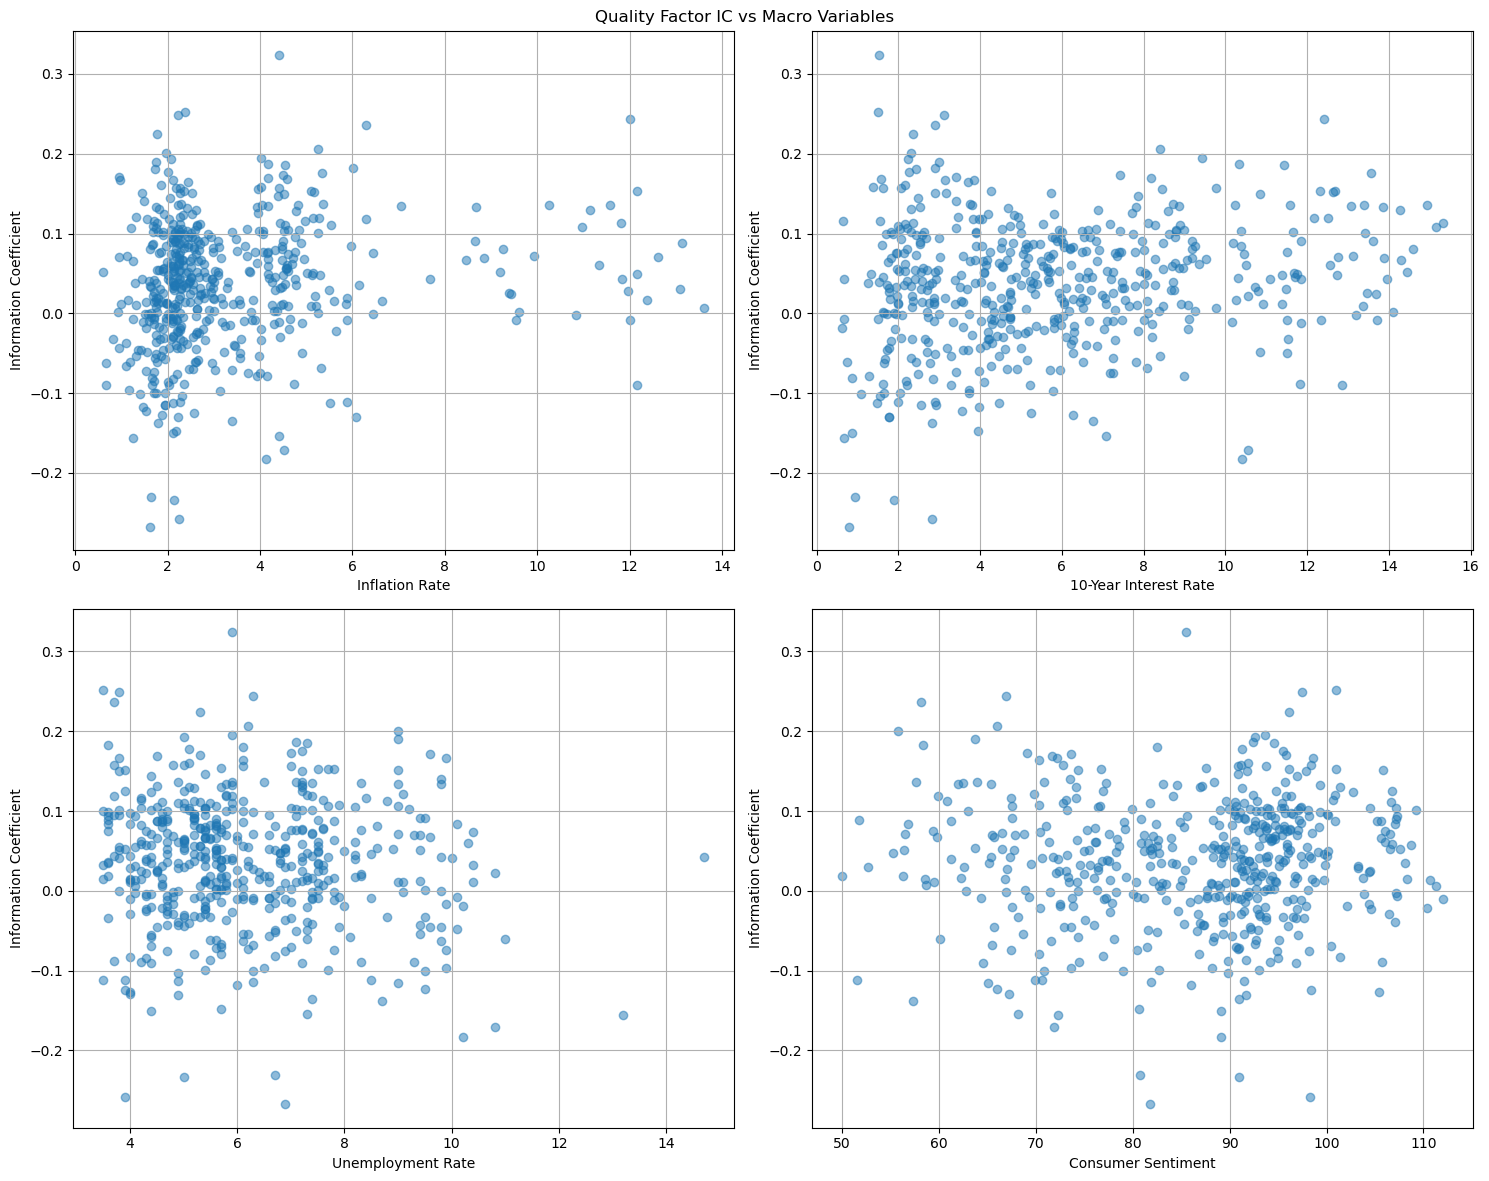

In [8]:
# Calculate monthly IC for quality factor
def calculate_monthly_ic(factor_data, returns_data, factor_name):
    merged_data = pd.merge(
        factor_data[['id', 'date', factor_name]], 
        returns_data[['id', 'date', 'next_month_return']], 
        on=['id', 'date']
    )
    return merged_data.groupby('date').apply(
        lambda x: x[factor_name].corr(x['next_month_return'], method='spearman')
    )

# Calculate future returns
price_data['next_month_return'] = price_data.groupby('id')['price'].shift(-1) / price_data['price'] - 1

# Calculate monthly IC
monthly_ic = calculate_monthly_ic(quality_data, price_data, 'quality')

# Process macro data
macro_data['date'] = pd.to_datetime(macro_data['date'])
macro_data = macro_data.set_index('date')

# Align IC with macro data
ic_macro = pd.DataFrame({
    'IC': monthly_ic,
    'Inflation': macro_data['INFL'],
    'Interest_Rate_10Y': macro_data['10YTR'],
    'Interest_Rate_1Y': macro_data['1YTR'],
    'Unemployment': macro_data['UNRATE'],
    'Consumer_Sentiment': macro_data['UMCSENT']
})

# Calculate rolling correlations between IC and macro variables
window = 36  # 3-year rolling window
rolling_corr = pd.DataFrame({
    'Inflation': ic_macro['IC'].rolling(window).corr(ic_macro['Inflation']),
    'Interest_Rate_10Y': ic_macro['IC'].rolling(window).corr(ic_macro['Interest_Rate_10Y']),
    'Interest_Rate_1Y': ic_macro['IC'].rolling(window).corr(ic_macro['Interest_Rate_1Y']),
    'Unemployment': ic_macro['IC'].rolling(window).corr(ic_macro['Unemployment']),
    'Consumer_Sentiment': ic_macro['IC'].rolling(window).corr(ic_macro['Consumer_Sentiment'])
})

# Plot rolling correlations
plt.figure(figsize=(15, 8))
for col in rolling_corr.columns:
    plt.plot(rolling_corr.index, rolling_corr[col], label=col)
plt.title('3-Year Rolling Correlation between Quality Factor IC and Macro Variables')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)
plt.show()

# Analyze recent period (last 2 years)
recent_period = slice('2021-01-01', '2022-12-31')
print("\nRecent Period Analysis (2021-2022):")
print("\nAverage Information Coefficient:")
print(f"IC: {ic_macro['IC'][recent_period].mean():.4f}")

print("\nMacro Environment:")
for col in ['Inflation', 'Interest_Rate_10Y', 'Interest_Rate_1Y', 'Unemployment', 'Consumer_Sentiment']:
    print(f"{col}:")
    print(f"Average: {ic_macro[col][recent_period].mean():.2f}")
    print(f"Change: {ic_macro[col][recent_period][-1] - ic_macro[col][recent_period][0]:.2f}")

# Calculate conditional IC based on macro regimes
def calculate_conditional_ic(ic_macro, variable, quantiles=3):
    # Create regimes based on macro variable
    ic_macro['Regime'] = pd.qcut(ic_macro[variable], quantiles, labels=['Low', 'Medium', 'High'])
    
    # Calculate average IC for each regime
    regime_ic = ic_macro.groupby('Regime')['IC'].agg(['mean', 'std', 'count'])
    return regime_ic

# Analyze IC in different macro regimes
print("\nQuality Factor Performance in Different Macro Regimes:")
macro_variables = ['Inflation', 'Interest_Rate_10Y', 'Unemployment']
for var in macro_variables:
    print(f"\n{var} Regimes:")
    regime_analysis = calculate_conditional_ic(ic_macro, var)
    print(regime_analysis.round(4))

# Plot IC vs key macro variables
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Quality Factor IC vs Macro Variables')

# Inflation
axes[0, 0].scatter(ic_macro['Inflation'], ic_macro['IC'], alpha=0.5)
axes[0, 0].set_xlabel('Inflation Rate')
axes[0, 0].set_ylabel('Information Coefficient')
axes[0, 0].grid(True)

# Interest Rate
axes[0, 1].scatter(ic_macro['Interest_Rate_10Y'], ic_macro['IC'], alpha=0.5)
axes[0, 1].set_xlabel('10-Year Interest Rate')
axes[0, 1].set_ylabel('Information Coefficient')
axes[0, 1].grid(True)

# Unemployment
axes[1, 0].scatter(ic_macro['Unemployment'], ic_macro['IC'], alpha=0.5)
axes[1, 0].set_xlabel('Unemployment Rate')
axes[1, 0].set_ylabel('Information Coefficient')
axes[1, 0].grid(True)

# Consumer Sentiment
axes[1, 1].scatter(ic_macro['Consumer_Sentiment'], ic_macro['IC'], alpha=0.5)
axes[1, 1].set_xlabel('Consumer Sentiment')
axes[1, 1].set_ylabel('Information Coefficient')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show() 

# Cell 8: Predictive power and the economic environment

This cell analyzes how macroeconomic conditions affect the quality factor's predictive power and performance.

## Main Components:

### 1. IC Calculation with Macro Context
- Calculates exponentially weighted ICs
- Incorporates macro variable relationships:
  - Inflation (INFL)
  - Interest rates (10Y and 1Y)
  - Unemployment rate
  - Consumer sentiment

### 2. Rolling Correlation Analysis
- Implements 3-year rolling correlations between:
  - Quality factor IC
  - Various macro variables
- Tracks relationship evolution over time
- Identifies macro sensitivity patterns

### 3. Regime Analysis
- Segments performance by macro regimes:
  - Low/Medium/High inflation periods
  - Interest rate environments
  - Employment conditions
- Evaluates factor behavior in different regimes

### 4. Recent Period Focus (2021-2022)
- Detailed analysis of recent performance
- Examines impact of:
  - Rising inflation
  - Interest rate changes
  - Post-COVID economic conditions
- Provides forward-looking insights

### 5. Visualization
- Creates comprehensive visual analysis:
  - Rolling correlation plots
  - Scatter plots of IC vs macro variables
  - Regime performance comparisons
  - Recent period trends

### 6. Economic Environment Assessment
- Evaluates current macro conditions
- Analyzes factor resilience
- Identifies potential risks and opportunities
- Provides strategic recommendations

## Purpose:
This cell examines how the quality factor's effectiveness varies with macroeconomic conditions, helping investors understand and adapt to changing market environments.

## Key Insights:
- Macro condition impacts
- Factor resilience analysis
- Regime-dependent behavior
- Current environment implications

## Strategic Applications:
- Risk management guidance
- Strategy adaptation recommendations
- Timing considerations
- Portfolio adjustment insights

Creating quality factors...


C:\Users\12116\AppData\Local\Temp\ipykernel_59136\159435408.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 4.28446816e-01 -2.37807607e-01 -7.42632066e-01  2.66297232e-02
 -1.33587971e-01 -1.03330930e+00  2.23303609e-01  2.29502735e-01
  1.26291460e+00  1.09200224e-01  8.73819056e-01 -7.91955418e-01
 -2.77990836e-01  1.25022848e-01 -4.19368647e-01  4.97886945e-01
  2.96564413e-01 -1.38280417e-01  2.97029048e-01  1.21048946e+00
 -1.49772108e+00  1.61148132e+00 -3.01565258e-01  3.30714029e-01
 -7.22760532e-03  9.94902076e-01  1.41062464e+00 -8.08494470e-01
  4.04832515e-01 -3.42614030e-02 -2.51569827e-01  4.59543252e-02
  7.18503790e-01 -2.74462891e-01 -4.28918742e-01  8.99738970e-01
 -1.83448729e-01  5.75575613e-01  1.83628177e-01 -1.82689319e+00
 -4.95763724e-01 -4.64970848e-02  1.03349586e-01 -1.16752769e+00
 -7.31069581e-01 -2.35714469e-01 -4.23858313e-01  8.24129491e-01
 -6.98642339e-01  3.54729461e-01  9

Running backtests...

Performance Comparison:
              Original Quality  Dynamic IC-Weighted  Momentum-Weighted
Mean Return           0.104364             0.107805           0.097667
St. Dev.              0.137200             0.137441           0.140591
RR Ratio              0.760668             0.784371           0.694688
% Positive            0.648148             0.652778           0.652778
Worst Month          -0.140865            -0.137749          -0.153055
Best Month            0.106777             0.105896           0.104789
Max DrawDown         -0.455186            -0.456492          -0.487856


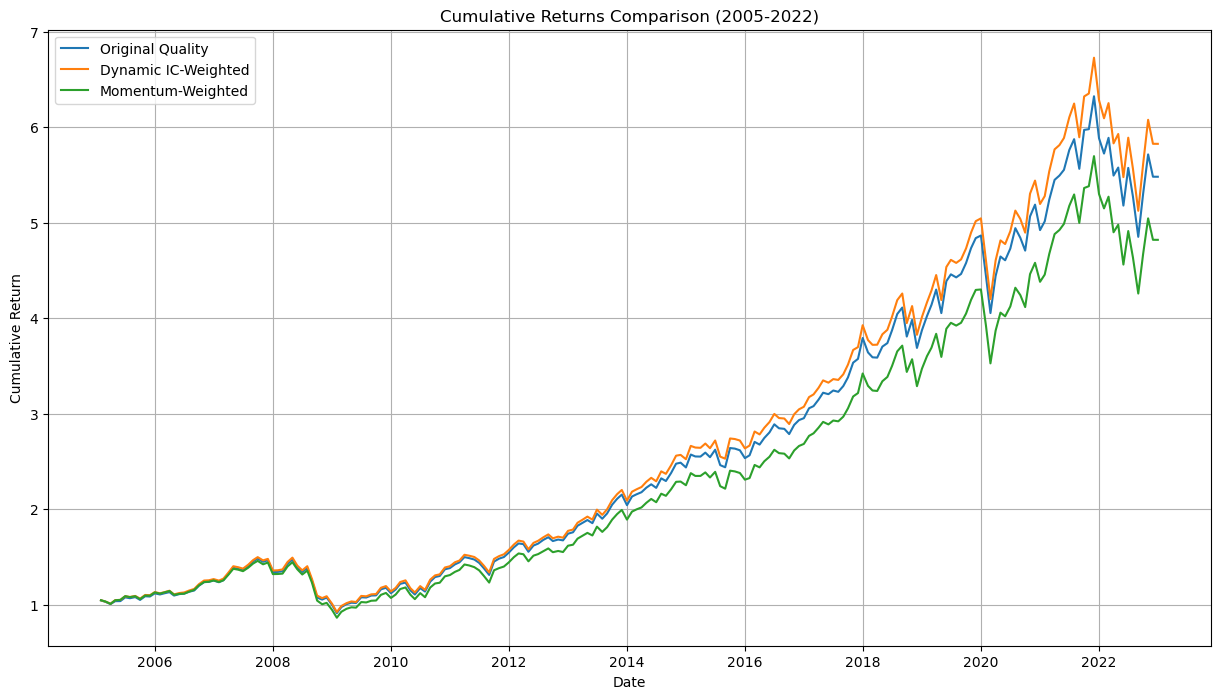

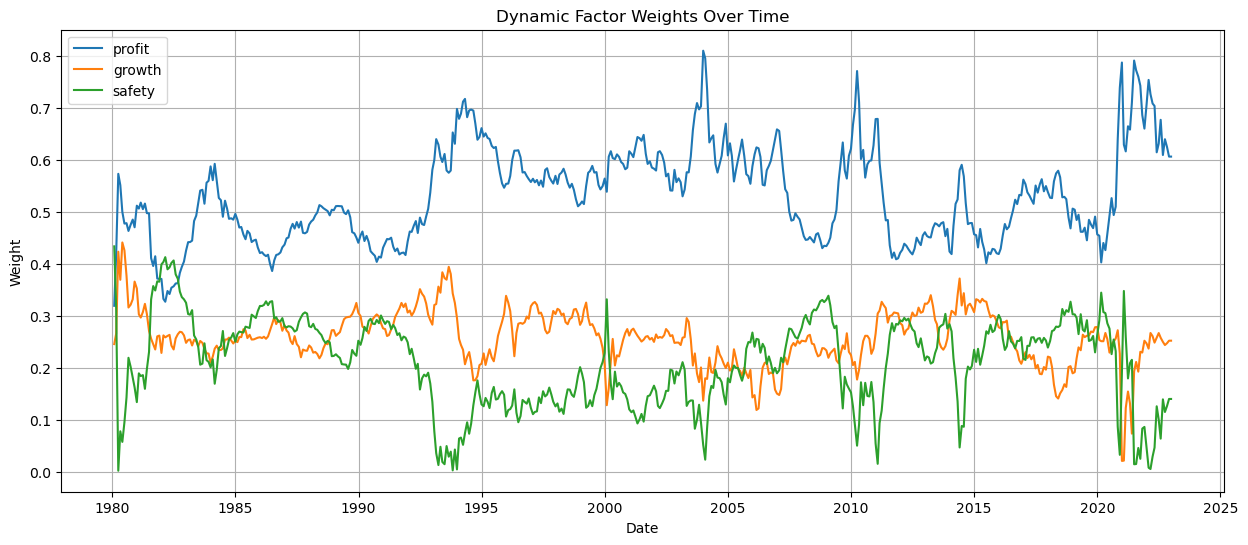

In [9]:
# Function to calculate exponentially weighted IC
def calculate_exp_weighted_ic(factor_data, price_data, factor_name, half_life=12):
    monthly_ics = []
    
    # Calculate returns
    price_data = price_data.copy()
    price_data['next_month_return'] = price_data.groupby('id')['price'].shift(-1) / price_data['price'] - 1
    
    for date in factor_data['date'].unique():
        # Get factor and returns for the same date
        factor_values = factor_data[factor_data['date'] == date]
        returns = price_data[price_data['date'] == date]
        
        # Merge on ID to ensure alignment
        merged = pd.merge(factor_values, returns[['id', 'next_month_return']], on='id', how='inner')
        
        if len(merged) > 0:
            ic = merged[factor_name].corr(merged['next_month_return'], method='spearman')
            monthly_ics.append((date, ic))
    
    ic_series = pd.DataFrame(monthly_ics, columns=['date', 'ic']).set_index('date')
    return ic_series['ic'].ewm(halflife=half_life).mean()

# Function to create dynamic weighted quality score
def create_dynamic_weighted_quality(profit_data, growth_data, safety_data, price_data, half_life=12):
    # Calculate ICs for each factor
    profit_ic = calculate_exp_weighted_ic(profit_data, price_data, 'profit', half_life)
    growth_ic = calculate_exp_weighted_ic(growth_data, price_data, 'growth', half_life)
    safety_ic = calculate_exp_weighted_ic(safety_data, price_data, 'safety', half_life)
    
    # Calculate dynamic weights
    total_ic = abs(profit_ic) + abs(growth_ic) + abs(safety_ic)
    weights = pd.DataFrame({
        'profit': abs(profit_ic) / total_ic,
        'growth': abs(growth_ic) / total_ic,
        'safety': abs(safety_ic) / total_ic
    }).fillna(1/3)  # Use equal weights if no IC available
    
    # Create weighted quality score
    quality_data = pd.merge(profit_data[['date', 'id', 'profit']], 
                          growth_data[['date', 'id', 'growth']], 
                          on=['date', 'id'])
    quality_data = pd.merge(quality_data, 
                          safety_data[['date', 'id', 'safety']], 
                          on=['date', 'id'])
    
    quality_data['quality'] = 0
    for date in weights.index:
        mask = quality_data['date'] == date
        if mask.any():
            w = weights.loc[date]
            quality_data.loc[mask, 'quality'] = (
                quality_data.loc[mask, 'profit'] * w['profit'] +
                quality_data.loc[mask, 'growth'] * w['growth'] +
                quality_data.loc[mask, 'safety'] * w['safety']
            )
    
    return quality_data[['date', 'id', 'quality']], weights

# Create momentum-adjusted quality score
def create_momentum_weighted_quality(profit_data, growth_data, safety_data):
    # Merge factor data
    quality_data = pd.merge(profit_data[['date', 'id', 'profit']], 
                          growth_data[['date', 'id', 'growth']], 
                          on=['date', 'id'])
    quality_data = pd.merge(quality_data, 
                          safety_data[['date', 'id', 'safety']], 
                          on=['date', 'id'])
    
    # Sort data for rolling calculations
    quality_data = quality_data.sort_values(['id', 'date'])
    
    # Calculate 6-month momentum for each factor
    for factor in ['profit', 'growth', 'safety']:
        quality_data[f'{factor}_mom'] = quality_data.groupby('id')[factor].transform(
            lambda x: x.rolling(window=6, min_periods=1).mean()
        )
    
    # Calculate quality score using momentum weights
    quality_data['quality'] = 0
    for date in quality_data['date'].unique():
        mask = quality_data['date'] == date
        if mask.any():
            mom_values = [quality_data.loc[mask, f'{f}_mom'].mean() for f in ['profit', 'growth', 'safety']]
            total_mom = sum(abs(m) for m in mom_values)
            if total_mom != 0:  # Avoid division by zero
                weights = [abs(m)/total_mom for m in mom_values]
            else:
                weights = [1/3, 1/3, 1/3]  # Equal weights if no momentum
            
            quality_data.loc[mask, 'quality'] = (
                quality_data.loc[mask, 'profit'] * weights[0] +
                quality_data.loc[mask, 'growth'] * weights[1] +
                quality_data.loc[mask, 'safety'] * weights[2]
            )
    
    return quality_data[['date', 'id', 'quality']]

# Create quality factors
print("Creating quality factors...")
dynamic_quality, dynamic_weights = create_dynamic_weighted_quality(
    profit_data, growth_data, safety_data, price_data
)
momentum_quality = create_momentum_weighted_quality(profit_data, growth_data, safety_data)

# Backtest parameters
START_DATE = '2005-01-01'
END_DATE = '2022-12-31'
TOP_N = 250
LONG_EXPOSURE = 1.3
TRANSACTION_COST = 0.002

# Run backtests
print("Running backtests...")
def run_backtest(quality_data, name):
    monthly_returns, turnover, composition, performance = apmodule.ls_backtesting(
        quality_data.set_index(['date', 'id'])['quality'],
        price_data.set_index(['date', 'id'])['price'],
        market_cap_data.set_index(['date', 'id'])['market_cap'],
        start=START_DATE,
        end=END_DATE,
        frequency=1,
        t_cost=TRANSACTION_COST,
        N=TOP_N,
        active=LONG_EXPOSURE-1
    )
    return monthly_returns, performance

# Run backtests for all strategies
original_returns, original_perf = run_backtest(quality_data, 'Original Quality')
dynamic_returns, dynamic_perf = run_backtest(dynamic_quality, 'Dynamic IC-Weighted')
momentum_returns, momentum_perf = run_backtest(momentum_quality, 'Momentum-Weighted')

# Create performance comparison table
print("\nPerformance Comparison:")
performance_comparison = pd.concat([
    original_perf['LS Portfolio'],
    dynamic_perf['LS Portfolio'],
    momentum_perf['LS Portfolio']
], axis=1)
performance_comparison.columns = ['Original Quality', 'Dynamic IC-Weighted', 'Momentum-Weighted']
print(performance_comparison)

# Plot cumulative returns
plt.figure(figsize=(15, 8))
for returns, name in [(original_returns, 'Original Quality'),
                     (dynamic_returns, 'Dynamic IC-Weighted'),
                     (momentum_returns, 'Momentum-Weighted')]:
    cumulative_returns = (1 + returns['LS Portfolio']).cumprod()
    plt.plot(cumulative_returns.index, cumulative_returns, label=name)

plt.title('Cumulative Returns Comparison (2005-2022)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Plot factor weights over time
plt.figure(figsize=(15, 6))
for factor in dynamic_weights.columns:
    plt.plot(dynamic_weights.index, dynamic_weights[factor], label=factor)
plt.title('Dynamic Factor Weights Over Time')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.legend()
plt.grid(True)
plt.show() 

# Cell 9: An Alternative Way to Combine the Factors

This cell explores and implements alternative approaches to combining the three components of the quality factor (profit, growth, and safety).

## Main Components:

### 1. Dynamic IC-Weighted Approach
- Implements dynamic weight calculation based on:
  - Historical Information Coefficients
  - Exponentially weighted performance
  - Rolling predictive power
- Adjusts weights based on component effectiveness

### 2. Momentum-Weighted Method
- Creates momentum-based factor combination:
  - 6-month factor momentum calculation
  - Dynamic weight adjustment
  - Trend-following integration
- Captures factor timing effects

### 3. Performance Comparison
- Evaluates three different approaches:
  - Original equal-weighted quality
  - Dynamic IC-weighted quality
  - Momentum-weighted quality
- Comprehensive performance metrics:
  - Returns
  - Sharpe ratios
  - Maximum drawdowns
  - Win rates

### 4. Weight Analysis
- Tracks weight evolution over time
- Analyzes weight stability
- Examines component contributions
- Identifies regime changes

### 5. Visualization
- Creates comparative analysis charts:
  - Cumulative returns comparison
  - Dynamic weight evolution
  - Performance metric comparisons
  - Risk-return trade-offs

### 6. Implementation Considerations
- Transaction cost impact
- Turnover analysis
- Practical implementation challenges
- Rebalancing implications

## Purpose:
This cell develops and tests alternative methods for combining factor components, aiming to improve upon the basic equal-weighted approach through more sophisticated combination techniques.

## Key Outputs:
- Alternative factor constructions
- Comparative performance analysis
- Dynamic weight patterns
- Implementation recommendations

## Practical Applications:
- Enhanced factor construction
- Dynamic allocation guidance
- Strategy improvement insights
- Portfolio optimization implications